# **Step3. 속성 기반 감정 분류**

**미션 : 리뷰 안에 담긴 11가지 속성 감성 분석하기(Aspect-Based Sentiment Analysis)**
1) 목표 : 속성 기반 감성 분석을 통해, 리뷰 내용을 속성에 따라 긍, 부정
으로 분류하는 모델 생성
2) 절차① : “[ASPECT] 속성 [SEP] 문장”
    * 데이터 전처리 : 데이터셋 구성, 토크나이즈
    * 스페셜 토큰 추가 + 모델의 임베딩 층 resizing
    * 파인튜닝 및 모델 평가
3) 절차② : “Aspect : 문장”
    * 데이터 전처리 : 데이터셋 구성, 토크나이즈
    * 파인튜닝 및 모델 평가
4) 성능 비교 : “Aspect : 문장”
    * 모델 별 : klue/bert-base, klue/RoBERTa-base
    * 전처리 별 : Case①, Case②
    * Macro Recall, Macro Precision, Macro F1-Score 비교

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [1]:
# 한글폰트 설치
import matplotlib as mpl
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'
!apt -qq -y install fonts-nanum

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Selecting previously unselected package fonts-nanum.
(Reading database ... 126455 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
# (Colab) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
!apt -qq -y install fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

import matplotlib as mpl
import matplotlib.font_manager as fm
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import torch

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [29]:
# 시각화용 코드를 만들어봤다.
def evaluate_by_aspect(val_df, aspects):
    # 이 함수는 검증 데이터프레임(val_df)과 평가할 속성 리스트(aspects)를 입력받습니다.
    # val_df는 'aspect', 'label'(실제값), 'pred'(예측값) 열을 포함해야 합니다.

    # 속성별 Precision, Recall, F1 점수를 저장할 리스트를 초기화합니다.
    precision_list = []
    recall_list = []
    f1_list = []

    # 입력된 모든 속성(aspect)에 대해 반복 평가를 수행합니다.
    for asp in aspects:
        # 1. 속성별 데이터 필터링
        # val_df에서 현재 속성(asp)과 일치하는 행만 추출합니다.
        df_asp = val_df[val_df['aspect'] == asp]

        # 2. 데이터가 없는 경우 처리
        # 만약 해당 속성을 가진 데이터가 없다면(len이 0이라면),
        if len(df_asp) == 0:
            # 점수를 0으로 기록하고 다음 속성으로 넘어갑니다. (나눗셈 오류 방지)
            precision_list.append(0)
            recall_list.append(0)
            f1_list.append(0)
            continue

        # 3. 속성별 평가지표 계산
        # sklearn.metrics의 함수들을 사용하여 Precision, Recall, F1-Score를 계산합니다.
        # df_asp['label']: 해당 속성에 대한 실제 레이블 (예: 긍정/부정)
        # df_asp['pred']: 해당 속성에 대한 모델의 예측값
        precision = precision_score(df_asp['label'], df_asp['pred'])
        recall = recall_score(df_asp['label'], df_asp['pred'])
        f1 = f1_score(df_asp['label'], df_asp['pred'])

        # 계산된 점수들을 리스트에 추가합니다.
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

        # 4. 상세 결과 출력
        print(f"=== {asp} ===")
        # classification_report를 사용하여 속성별 상세 성능 지표를 출력합니다.
        # target_names: 레이블 0과 1에 대한 이름을 지정합니다. (예: 0을 "Negative", 1을 "Positive")
        print(classification_report(df_asp['label'], df_asp['pred'], target_names=["Negative", "Positive"]))

    # 5. 시각화 준비
    # 막대 그래프의 x축 위치를 설정합니다. (속성의 개수만큼 0, 1, 2, ... 생성)
    x = np.arange(len(aspects))
    # 각 막대의 너비를 설정합니다. (Precision, Recall, F1 세 막대를 나란히 그리기 위함)
    width = 0.25

    # 6. 막대 그래프 그리기
    plt.figure(figsize=(12,6)) # 그래프 크기를 설정합니다.

    # Precision 막대: x 위치에서 왼쪽(width만큼)으로 이동하여 그립니다.
    plt.bar(x - width, precision_list, width, label='Precision', color='skyblue')
    # Recall 막대: x 위치 중앙에 그립니다.
    plt.bar(x, recall_list, width, label='Recall', color='salmon')
    # F1-Score 막대: x 위치에서 오른쪽(width만큼)으로 이동하여 그립니다.
    plt.bar(x + width, f1_list, width, label='F1-Score', color='limegreen')

    # x축 레이블 설정: x 위치에 속성 이름을 표시하고, 겹치지 않도록 45도 회전합니다.
    plt.xticks(x, aspects, rotation=45)
    # y축 범위를 0부터 1까지로 고정합니다. (점수이므로)
    plt.ylim(0,1)
    # y축 제목과 그래프 제목, 범례를 추가합니다.
    plt.ylabel('Score')
    plt.title('Aspect-Based Sentiment Classification Metrics')
    plt.legend()

    # 레이블이 잘리지 않도록 그래프 레이아웃을 조정합니다.
    plt.tight_layout()
    # 그래프를 화면에 출력합니다.
    plt.show()

### (2) 데이터 로딩
* data.csv 파일 로딩

In [4]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [5]:
data = pd.read_csv('data.csv')
data.head()

,text,aspect,label
0,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,포장,1
1,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,품질,1
2,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,보습,1
3,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,포장,0
4,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,기타,1


* 전제 데이터 중 10,000건만 샘플링
    * 학습 속도 고려

In [6]:
data1 = data.sample(10000, random_state=10)
data1.reset_index(drop=True, inplace=True)

### (3) GPU 설정
* GPU 사용을 위한 설정

In [7]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.방식① : [ASPECT] 속성 [SEP] 문장

* 두가지 모델에 대해서 튜닝을 시도해봅시다.
    * model_name1 = "klue/bert-base"
    * model_name2 = "klue/roberta-base"

### (1) 데이터 준비
* 데이터셋 분할 및 텐서 데이터셋 변환
* 토크나이징 함수 안에서,
    * "[ASPECT] 속성 [SEP] 문장" 형태로 수정
    * 토크나이징

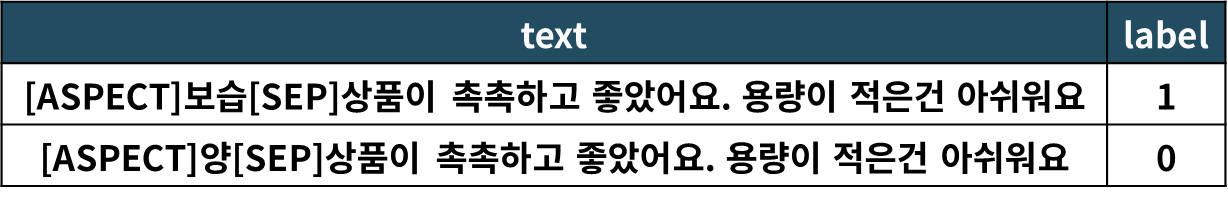

#### 1) 데이터셋 분할 및 텐서 데이터셋 변환

In [8]:
aspects = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

In [9]:
# train, val 데이터 분할
train, val = train_test_split(data1, random_state=10, test_size=0.3)

In [10]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

In [11]:
train_ts[:3]

{'text': ['항상 사용하는 거예요. 촉촉하고 좋아요. 피부에 잘 흡수되고 보들보들합니다. 이것만 쓰고 있어요. 샘플도 주셔서 잘 쓸 것 같습니다.',
  '이제야 알게 된 사실이 정말 한탄스러울 정도로 너무 좋은 제품을 소개 해드리려고 왔습니다!! 남자 향수 많이 사용했지만 이 향수가 향이 제일 좋은 것 같아요!! 바로 OOO 레전드 EDT 100ml입니다!! 이름 그대로 정말 레전드입니다!! 향이 은은하고 섹시해서 정말 뿌릴 때 마다 기분이 좋아요~ 잔향도 오래 가고 무엇보다 이거 뿌리고 나간 날에는 향이 좋다는 소리를 많이 듣는 것 같아요! 향수 디자인도 예쁘고 용량도 많아서 좋습니다!! 전체적인 품질이 상당히 좋은 향수가 아닌가 생각이 드네요!! 구입 후 만족도가 상당히 높은 제품이에요!! 추천 드리고 싶어요! 남자 향수는 OOO 레전드만 기억 하세요^^',
  '오래전부터 써오던 제품입니다. 향도 오래가지 않고 색상이 이전보다 녹색빛이 돌아서 정품이 아닌 것 같습니다.'],
 'aspect': ['보습', '품질', '외형'],
 'label': [1, 1, 0],
 '__index_level_0__': [5663, 2840, 4550]}

#### 2) 토크나이징
* "[ASPECT] 속성 [SEP] 문장" 형태로 수정
* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

* 토크나이저 준비 : 두 모델에 대한 토크나이저 로딩

In [12]:
model_name1 = "klue/bert-base"
model_name2 = "klue/roberta-base"

tokenizer_kb = AutoTokenizer.from_pretrained(model_name1)
tokenizer_kr = AutoTokenizer.from_pretrained(model_name2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

* 사용자 정의 스페셜 토큰 등록하기

In [13]:
# 사용자 정의 스페셜 토큰 목록
special_tokens_dict = {"additional_special_tokens": ["[ASPECT]"]}

# 토크나이저에 추가
num_added_toks_kb = tokenizer_kb.add_special_tokens(special_tokens_dict)
num_added_toks_kr = tokenizer_kr.add_special_tokens(special_tokens_dict)
print(f"Added {num_added_toks_kb} special tokens:{special_tokens_dict['additional_special_tokens']}")
print(f"Added {num_added_toks_kr} special tokens:{special_tokens_dict['additional_special_tokens']}")

# 왜 "[SEP]"는 스페셜 토큰으로 넣지 않을까?
# BERT, RoBERTa 등의 사전학습 모델은 [CLS], [SEP], [PAD] 등 필수 스페셜 토큰을 이미 내장하고 있기 때문
# [SEP] → 문장 구분, 시퀀스 끝 표시 등
# [CLS] → 문장 대표 벡터 사용
# [PAD] → padding용

Added 1 special tokens:['[ASPECT]']
Added 1 special tokens:['[ASPECT]']


* 토크나이징을 포함한 함수 생성 및 적용

In [14]:
# 모델 통합 전처리 함수
def preprocess_function(data, tokenizer):
  input_texts = ["[ASPECT] " + asp + " [SEP] " + sep for asp, sep in zip(data['aspect'], data['text'])]    # "[ASPECT] 속성 [SEP] 문장" 형태로 수정
  tokenized = tokenizer(input_texts, truncation=True, padding='max_length', max_length=128)     #text 컬럼을 가져와서 토크나이징함.
  # tokenized['labels'] = [list(map(float, labels)) for labels in data['label']]    #iterable(라벨에 0, 1 중 하나만 있음) 하지 못해서 오류가 발생
  tokenized['labels'] = [float(l) for l in data['label']]
  return tokenized

# 모델1 전처리 적용

train_ts_kb = train_ts.map(lambda x: preprocess_function(x, tokenizer_kb), batched=True)
val_ts_kb = val_ts.map(lambda x: preprocess_function(x, tokenizer_kb), batched=True)

# 모델2 전처리 함수


# 모델2 전처리 적용
train_ts_kr = train_ts.map(lambda x: preprocess_function(x, tokenizer_kr), batched=True)
val_ts_kr = val_ts.map(lambda x: preprocess_function(x, tokenizer_kr), batched=True)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

### (2) Fine-Tuning

In [15]:
# 학습속도를 높이기 위해서
# T4 확인.--> A100
# 데이터수를 줄이기 .sample(5000)
# per_device_train_batch_size = 64 # 128
# padding --> max_length = 128 조절
# 로라 파인튜닝
# 에포크 줄이기 (그대신 성능이 떨어질수 있음)

#### 1) 사전학습 모델 준비
* 모델 로드한 후
* 반드시 `모델.resize_token_embeddings(len(tokenizer))`

In [16]:
# 모델1
# label(클래스) 수 지정
num_labels = 2

model_kb = AutoModelForSequenceClassification.from_pretrained(
    model_name1,
    num_labels=num_labels,
)
model_kb.resize_token_embeddings(len(tokenizer_kb))

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(32001, 768, padding_idx=0)

In [17]:
# 모델2
model_kr = AutoModelForSequenceClassification.from_pretrained(
    model_name2,
    num_labels=num_labels,
)
model_kr.resize_token_embeddings(len(tokenizer_kr))

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(32001, 768, padding_idx=1)

#### 2) 학습 설정

* TrainingArguments 설정
    * 두 모델에 공통으로 하나만 설정해도 됨

In [18]:
# TrainingArguments 설정
training_args_as = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 3,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs_as',
    logging_steps = 10,
    report_to="tensorboard"
)

* Trainer 설정
    * 두 모델 각각 설정

In [19]:
# Trainer1 설정
trainer1 = Trainer(
    model=model_kb,                         # 학습할 모델
    args=training_args_as,                  # TrainingArguments
    train_dataset = train_ts_kb,
    eval_dataset = val_ts_kb,
    tokenizer = tokenizer_kb,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)


# Trainer2 설정
trainer2 = Trainer(
    model=model_kr,                         # 학습할 모델
    args=training_args_as,                  # TrainingArguments
    train_dataset = train_ts_kr,
    eval_dataset = val_ts_kr,
    tokenizer = tokenizer_kr,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)


/tmp/ipython-input-2123626790.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer1 = Trainer(
/tmp/ipython-input-2123626790.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer2 = Trainer(


#### 3) 학습

In [20]:
trainer1.train()

Epoch,Training Loss,Validation Loss
1,0.234400,0.237244
2,0.123500,0.213215
3,0.083200,0.228206


TrainOutput(global_step=657, training_loss=0.18361482908736626, metrics={'train_runtime': 531.3898, 'train_samples_per_second': 39.519, 'train_steps_per_second': 1.236, 'total_flos': 1381333040640000.0, 'train_loss': 0.18361482908736626, 'epoch': 3.0})

In [21]:
trainer2.train()

Epoch,Training Loss,Validation Loss
1,0.254500,0.282160
2,0.172200,0.203052
3,0.135300,0.269441


TrainOutput(global_step=657, training_loss=0.19794180227196925, metrics={'train_runtime': 524.3968, 'train_samples_per_second': 40.046, 'train_steps_per_second': 1.253, 'total_flos': 1381333040640000.0, 'train_loss': 0.19794180227196925, 'epoch': 3.0})

#### 4) 모델 검증평가

* 예측

In [22]:
# raw_pred1 = trainer.predict(val_ts)
# pred1 = raw_pred1.predictions.argmax(axis=1)    # 1, 0 으로 변환하는 코드
# true1 = raw_pred1.label_ids   # 정답 1, 0


In [23]:
# 모델1(kb) 예측

raw_pred1 = trainer1.predict(val_ts_kb)
preds1 = raw_pred1.predictions.argmax(axis=1)    # 1, 0 으로 변환하는 코드
labels1 = raw_pred1.label_ids   # 정답 1, 0

In [25]:
# 모델2(kr) 예측
raw_pred2 = trainer2.predict(val_ts_kr)
preds2 = raw_pred2.predictions.argmax(axis=1)    # 1, 0 으로 변환하는 코드
labels2 = raw_pred2.label_ids   # 정답 1, 0

* 평가 : model1

In [26]:
print("Model1(BERT) Accuracy:", accuracy_score(labels1, preds1))
print(classification_report(labels1, preds1, target_names=["Negative", "Positive"]))

Model1(BERT) Accuracy: 0.927
              precision    recall  f1-score   support

    Negative       0.91      0.83      0.87       878
    Positive       0.93      0.97      0.95      2122

    accuracy                           0.93      3000
   macro avg       0.92      0.90      0.91      3000
weighted avg       0.93      0.93      0.93      3000



In [27]:
# pandas로 변환 (val_ts → 원래의 데이터셋 형태 필요)
val1 = val_ts_kb.to_pandas()
val1['pred'] = preds1

# 일부 결과 확인
val1[['text', 'aspect', 'label', 'pred']].head()

,text,aspect,label,pred
0,배송은 느렸구요 사용감은 좋아요. 남성 향이 강하니 참고하시고 세정력은 좋네요.,기능,1,1
1,안녕하세요~ 좋아하는 남친에게 ㅇㅇㅇ향수 어떨까요~ 겨울이 생일인 남자친구에게 선물...,편의성,1,1
2,용량도 크고 향도 강하지 않아서 괜찮습니다. 자극적이지 않아서 좋은 것 같아요.,피부,1,1
3,이름대로 무향에 보들보들 발림성이 부드러운 립밤이네요 아이가 용기의 OOO도 OOO...,향,1,1
4,다른 립밤은 온도에 따라 녹고 하는데 그런 것 없이 입술 탄력이 쫀쫀하게 잘 유지되...,향,1,1


=== 보습 ===
              precision    recall  f1-score   support

    Negative       0.94      0.87      0.90        69
    Positive       0.97      0.99      0.98       323

    accuracy                           0.97       392
   macro avg       0.96      0.93      0.94       392
weighted avg       0.97      0.97      0.97       392

=== 기능 ===
              precision    recall  f1-score   support

    Negative       0.92      0.74      0.82       108
    Positive       0.91      0.98      0.94       303

    accuracy                           0.91       411
   macro avg       0.92      0.86      0.88       411
weighted avg       0.92      0.91      0.91       411

=== 밀착 ===
              precision    recall  f1-score   support

    Negative       0.92      0.84      0.88        92
    Positive       0.94      0.97      0.96       241

    accuracy                           0.93       333
   macro avg       0.93      0.90      0.92       333
weighted avg       0.93      0.93      0.

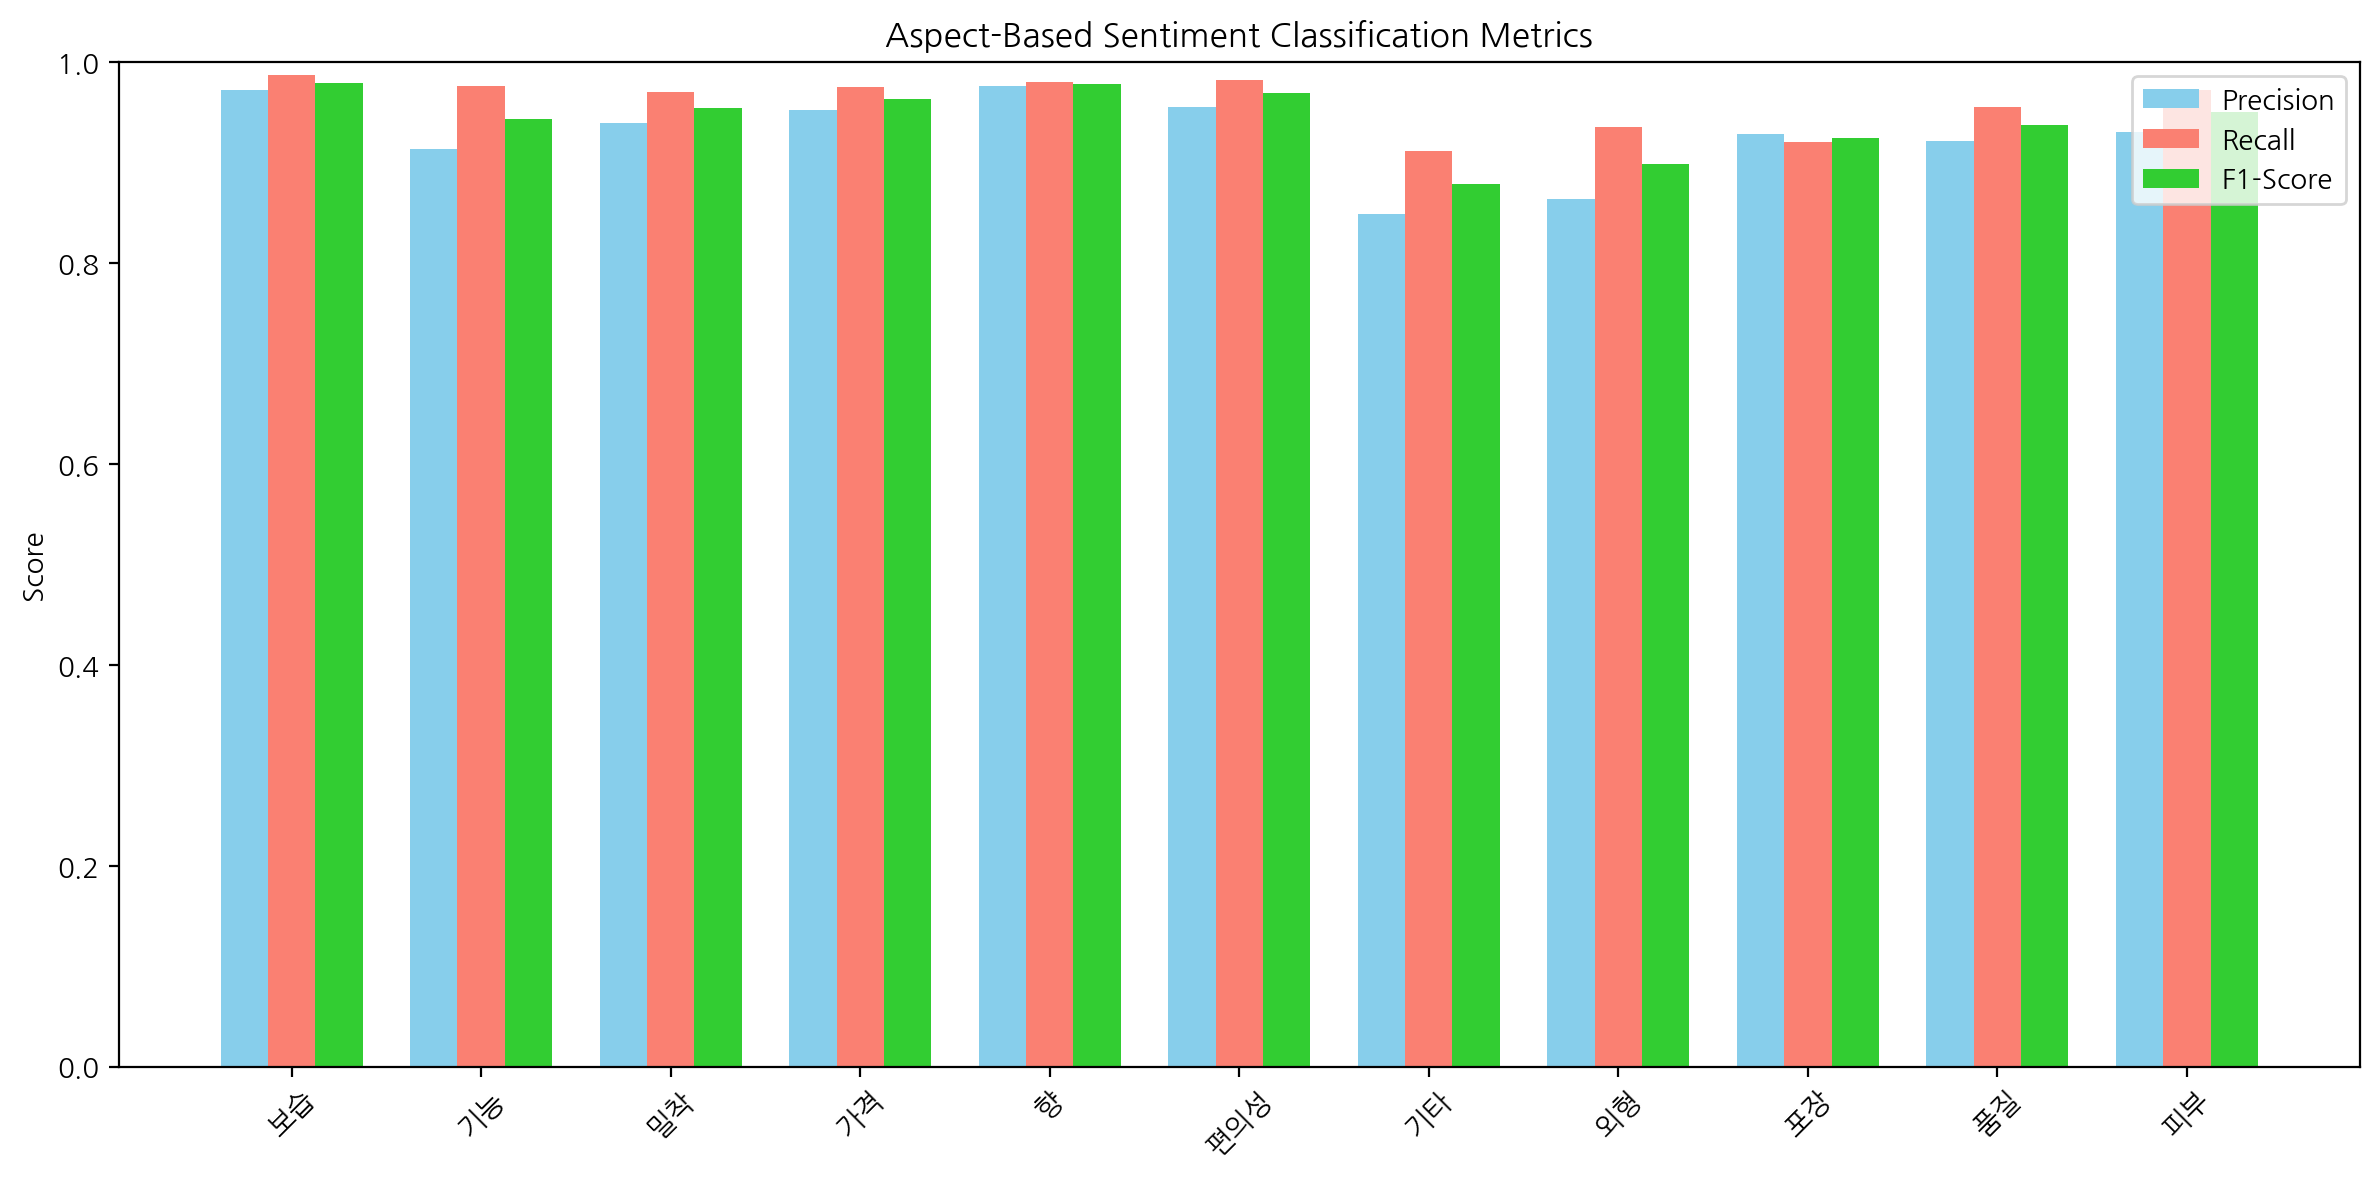

In [30]:
val_df_kb = val_ts_kb.to_pandas()
val_df_kb['pred'] = preds1
evaluate_by_aspect(val_df_kb, aspects)

* 평가 : model2

In [31]:
print("Model2(RoBERTa) Accuracy:", accuracy_score(labels2, preds2))
print(classification_report(labels2, preds2, target_names=["Negative", "Positive"]))

Model2(RoBERTa) Accuracy: 0.9263333333333333
              precision    recall  f1-score   support

    Negative       0.89      0.85      0.87       878
    Positive       0.94      0.96      0.95      2122

    accuracy                           0.93      3000
   macro avg       0.92      0.90      0.91      3000
weighted avg       0.93      0.93      0.93      3000



In [32]:
# pandas로 변환 (val_ts → 원래의 데이터셋 형태 필요)
val2 = val_ts_kr.to_pandas()
val2['pred'] = preds2

# 일부 결과 확인
val2[['text', 'aspect', 'label', 'pred']].head()

,text,aspect,label,pred
0,배송은 느렸구요 사용감은 좋아요. 남성 향이 강하니 참고하시고 세정력은 좋네요.,기능,1,1
1,안녕하세요~ 좋아하는 남친에게 ㅇㅇㅇ향수 어떨까요~ 겨울이 생일인 남자친구에게 선물...,편의성,1,1
2,용량도 크고 향도 강하지 않아서 괜찮습니다. 자극적이지 않아서 좋은 것 같아요.,피부,1,1
3,이름대로 무향에 보들보들 발림성이 부드러운 립밤이네요 아이가 용기의 OOO도 OOO...,향,1,1
4,다른 립밤은 온도에 따라 녹고 하는데 그런 것 없이 입술 탄력이 쫀쫀하게 잘 유지되...,향,1,1


=== 보습 ===
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89        69
    Positive       0.98      0.98      0.98       323

    accuracy                           0.96       392
   macro avg       0.94      0.93      0.93       392
weighted avg       0.96      0.96      0.96       392

=== 기능 ===
              precision    recall  f1-score   support

    Negative       0.87      0.79      0.83       108
    Positive       0.93      0.96      0.94       303

    accuracy                           0.91       411
   macro avg       0.90      0.87      0.88       411
weighted avg       0.91      0.91      0.91       411

=== 밀착 ===
              precision    recall  f1-score   support

    Negative       0.91      0.77      0.84        92
    Positive       0.92      0.97      0.94       241

    accuracy                           0.92       333
   macro avg       0.91      0.87      0.89       333
weighted avg       0.92      0.92      0.

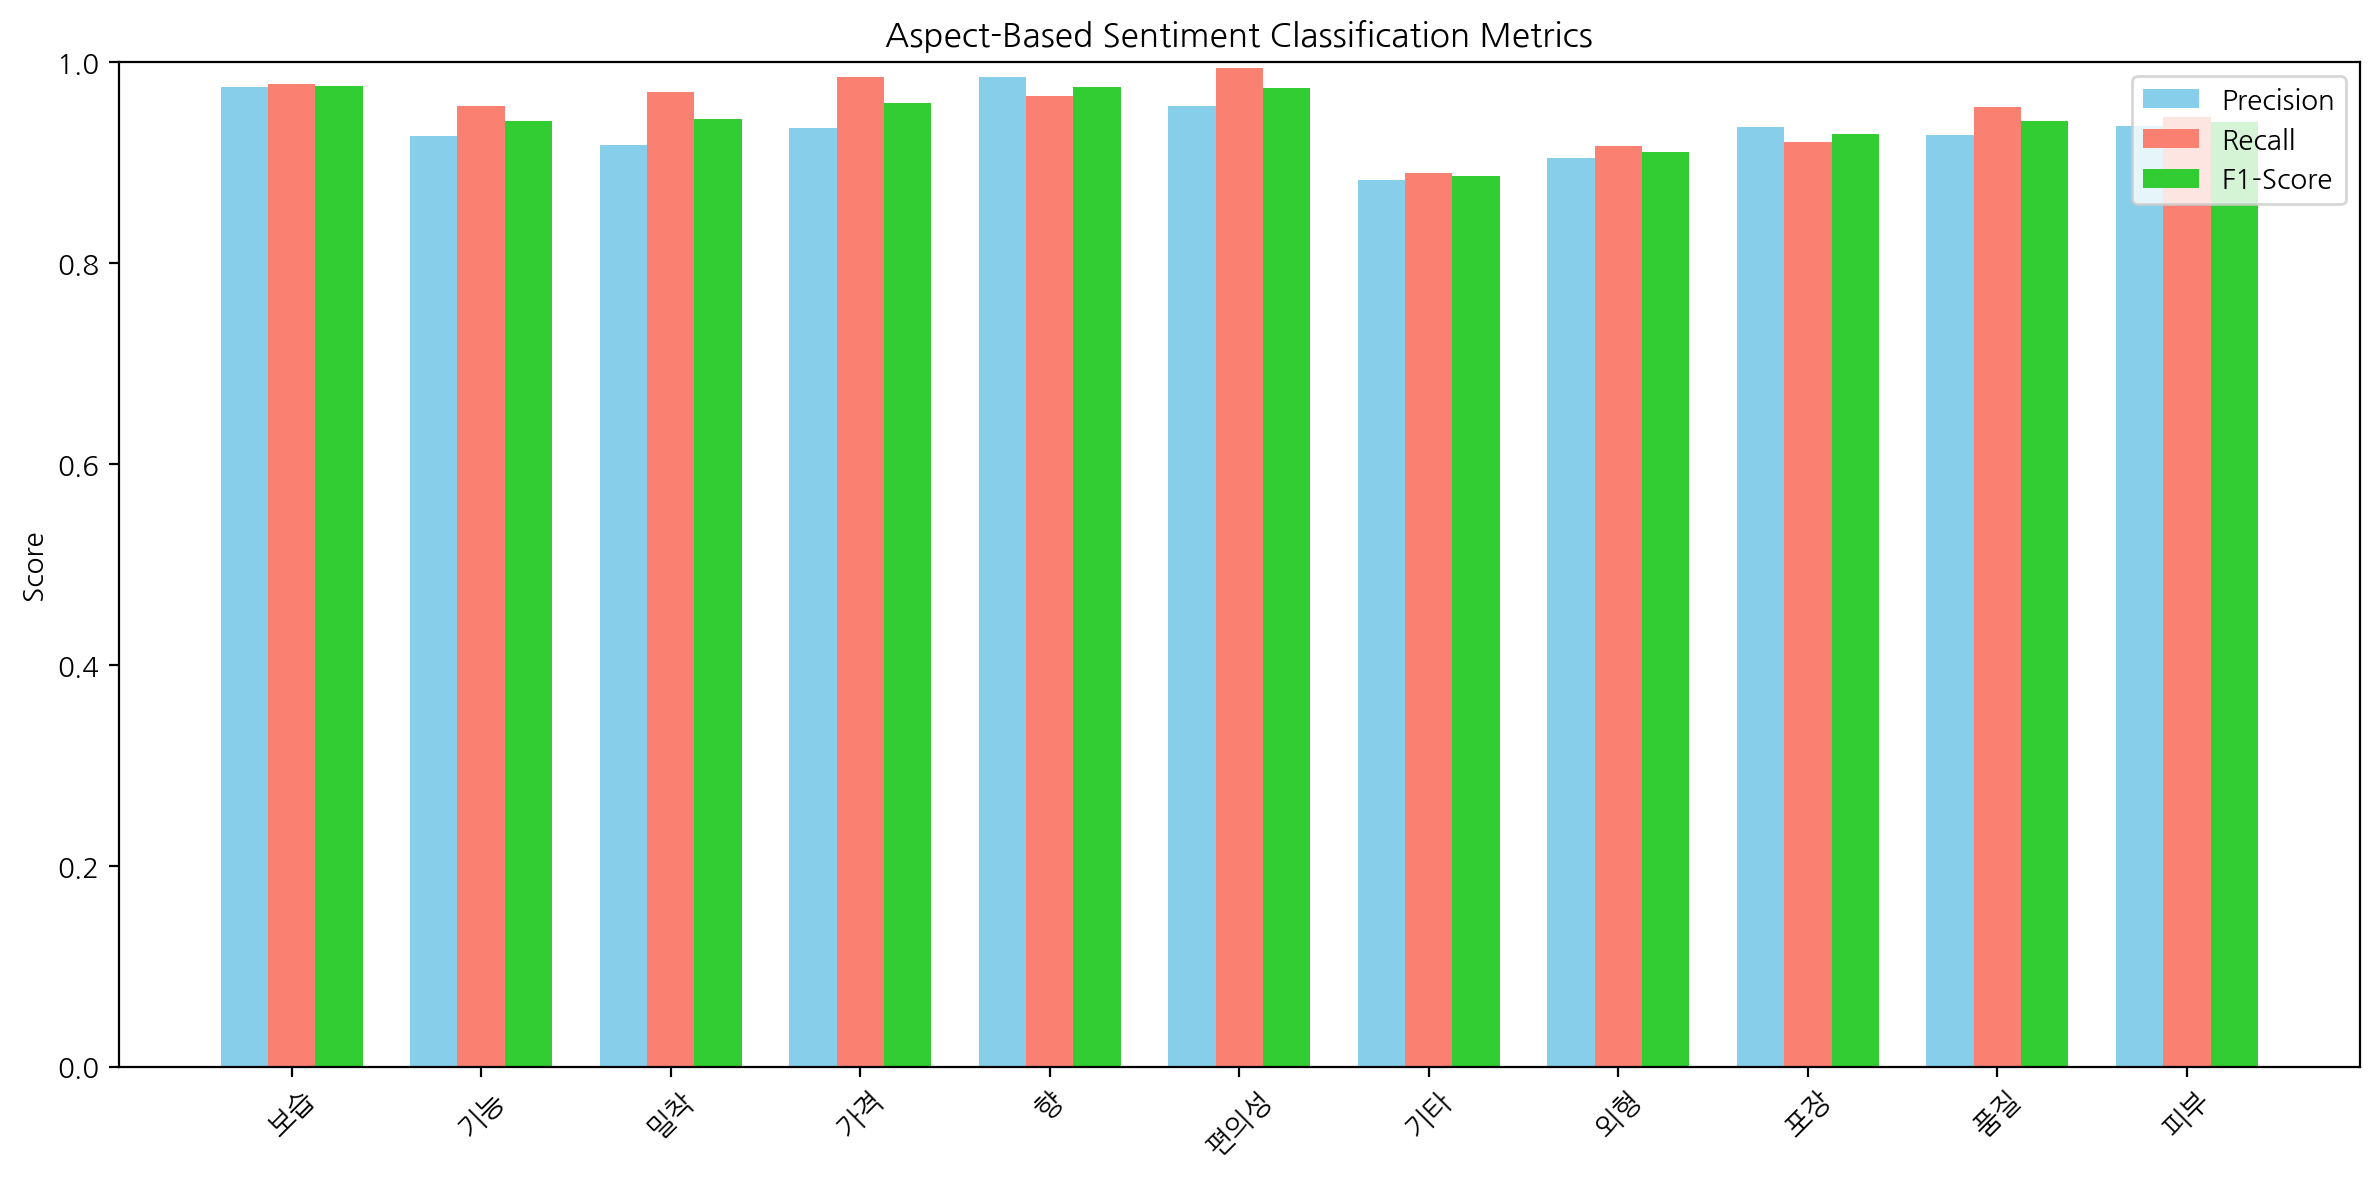

In [33]:
val_df_kr = val_ts_kr.to_pandas()
val_df_kr['pred'] = preds2
evaluate_by_aspect(val_df_kr, aspects)

## 3.방식② : 속성 : 문장

* 두가지 모델에 대해서 튜닝을 시도해봅시다.
    * model_name1 = "klue/bert-base"
    * model_name2 = "klue/roberta-base"

### (1) 데이터 준비
* 데이터셋 분할 및 텐서 데이터셋 변환
* 토크나이징 함수 안에서,
    * "ASPECT : 문장" 형태로 수정
    * 토크나이징

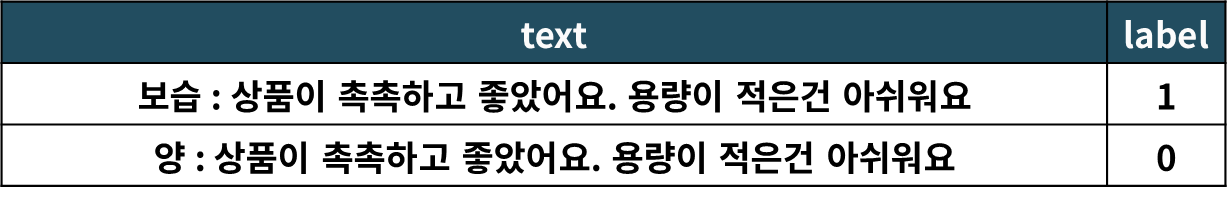

#### 1) 데이터셋 분할 및 텐서 데이터셋 변환

In [34]:
aspects = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

In [35]:
# train, val 데이터 분할
train, val = train_test_split(data1, test_size=0.3, random_state=10)

In [36]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

#### 2) 토크나이징
* "ASPECT : 문장" 형태로 수정
* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

* 토크나이저 준비 : 두 모델에 대한 토크나이저 로딩

In [37]:
model_name1 = "klue/bert-base"
model_name2 = "klue/roberta-base"

# 토크나이저 로드
tokenizer_kb = AutoTokenizer.from_pretrained(model_name1)
tokenizer_kr = AutoTokenizer.from_pretrained(model_name2)

* 토크나이징을 포함한 함수 생성 및 적용

In [38]:
# 모델1 전처리 함수
def preprocess_function2(data, tokenizer):
    input_texts = [asp + " : " + txt for asp, txt in zip(data['aspect'], data['text'])]  # "ASPECT : 문장"
    tokenized = tokenizer(input_texts, truncation=True, padding='max_length', max_length=128)
    tokenized['labels'] = [float(l) for l in data['label']]  # 이진 라벨
    return tokenized

# 모델1 전처리 적용
train_ts_kb = train_ts.map(lambda x: preprocess_function2(x, tokenizer_kb), batched=True)
val_ts_kb = val_ts.map(lambda x: preprocess_function2(x, tokenizer_kb), batched=True)

# 모델2 전처리 함수


# 모델2 전처리 적용
train_ts_kr = train_ts.map(lambda x: preprocess_function2(x, tokenizer_kr), batched=True)
val_ts_kr = val_ts.map(lambda x: preprocess_function2(x, tokenizer_kr), batched=True)


Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

### (2) Fine-Tuning

#### 1) 사전학습 모델 준비

In [39]:
num_labels = 2  # 이진 분류

# 모델1
model_kb = AutoModelForSequenceClassification.from_pretrained(
    model_name1,
    num_labels=num_labels
)
model_kb.resize_token_embeddings(len(tokenizer_kb))


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(32000, 768, padding_idx=0)

In [40]:
# 모델2
model_kr = AutoModelForSequenceClassification.from_pretrained(
    model_name2,
    num_labels=num_labels
)
model_kr.resize_token_embeddings(len(tokenizer_kr))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(32000, 768, padding_idx=1)

#### 2) 학습 설정

* TrainingArguments 설정
    * 두 모델에 공통으로 하나만 설정해도 됨

In [41]:
training_args_ct = TrainingArguments(
    output_dir='./results2',
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.02,
    load_best_model_at_end=True,
    logging_dir='./logs_as2',
    logging_steps=10,
    report_to="tensorboard"
)

* Trainer 설정
    * 두 모델 각각 설정

In [42]:
# Trainer1_ct
trainer1_ct = Trainer(
    model=model_kb,
    args=training_args_ct,
    train_dataset=train_ts_kb,
    eval_dataset=val_ts_kb,
    tokenizer=tokenizer_kb,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Trainer2_ct
trainer2_ct = Trainer(
    model=model_kr,
    args=training_args_ct,
    train_dataset=train_ts_kr,
    eval_dataset=val_ts_kr,
    tokenizer=tokenizer_kr,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

/tmp/ipython-input-2419101912.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer1_ct = Trainer(
/tmp/ipython-input-2419101912.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer2_ct = Trainer(


#### 3) 학습

In [43]:
trainer1_ct.train()

Epoch,Training Loss,Validation Loss
1,0.268100,0.272852
2,0.146100,0.212026
3,0.081700,0.247955


TrainOutput(global_step=657, training_loss=0.19697861221464438, metrics={'train_runtime': 553.2759, 'train_samples_per_second': 37.956, 'train_steps_per_second': 1.187, 'total_flos': 1381333040640000.0, 'train_loss': 0.19697861221464438, 'epoch': 3.0})

In [44]:
trainer2_ct.train()

Epoch,Training Loss,Validation Loss
1,0.221600,0.232647
2,0.185600,0.193185
3,0.106200,0.239554


TrainOutput(global_step=657, training_loss=0.1882615971238646, metrics={'train_runtime': 542.7442, 'train_samples_per_second': 38.692, 'train_steps_per_second': 1.211, 'total_flos': 1381333040640000.0, 'train_loss': 0.1882615971238646, 'epoch': 3.0})

#### 4) 모델 검증평가

* 예측

In [45]:
# 모델1 예측
raw_pred1_case2 = trainer1_ct.predict(val_ts_kb)
preds1_case2 = raw_pred1_case2.predictions.argmax(axis=1)
labels1_case2 = raw_pred1_case2.label_ids

In [46]:
# 모델2 예측
raw_pred2_case2 = trainer2_ct.predict(val_ts_kr)
preds2_case2 = raw_pred2_case2.predictions.argmax(axis=1)
labels2_case2 = raw_pred2_case2.label_ids

* 평가

In [47]:
# 평가
print("Model1(BERT) Accuracy:", accuracy_score(labels1_case2, preds1_case2))
print(classification_report(labels1_case2, preds1_case2, target_names=["Negative", "Positive"]))

val1 = val_ts_kb.to_pandas()
val1['pred'] = preds1_case2
val1[['text', 'aspect', 'label', 'pred']].head()

Model1(BERT) Accuracy: 0.9176666666666666
              precision    recall  f1-score   support

    Negative       0.90      0.81      0.85       878
    Positive       0.92      0.96      0.94      2122

    accuracy                           0.92      3000
   macro avg       0.91      0.89      0.90      3000
weighted avg       0.92      0.92      0.92      3000



,text,aspect,label,pred
0,배송은 느렸구요 사용감은 좋아요. 남성 향이 강하니 참고하시고 세정력은 좋네요.,기능,1,1
1,안녕하세요~ 좋아하는 남친에게 ㅇㅇㅇ향수 어떨까요~ 겨울이 생일인 남자친구에게 선물...,편의성,1,1
2,용량도 크고 향도 강하지 않아서 괜찮습니다. 자극적이지 않아서 좋은 것 같아요.,피부,1,1
3,이름대로 무향에 보들보들 발림성이 부드러운 립밤이네요 아이가 용기의 OOO도 OOO...,향,1,1
4,다른 립밤은 온도에 따라 녹고 하는데 그런 것 없이 입술 탄력이 쫀쫀하게 잘 유지되...,향,1,1


=== 보습 ===
              precision    recall  f1-score   support

    Negative       0.91      0.86      0.88        69
    Positive       0.97      0.98      0.98       323

    accuracy                           0.96       392
   macro avg       0.94      0.92      0.93       392
weighted avg       0.96      0.96      0.96       392

=== 기능 ===
              precision    recall  f1-score   support

    Negative       0.91      0.69      0.78       108
    Positive       0.90      0.98      0.94       303

    accuracy                           0.90       411
   macro avg       0.91      0.83      0.86       411
weighted avg       0.90      0.90      0.90       411

=== 밀착 ===
              precision    recall  f1-score   support

    Negative       0.89      0.82      0.85        92
    Positive       0.93      0.96      0.95       241

    accuracy                           0.92       333
   macro avg       0.91      0.89      0.90       333
weighted avg       0.92      0.92      0.

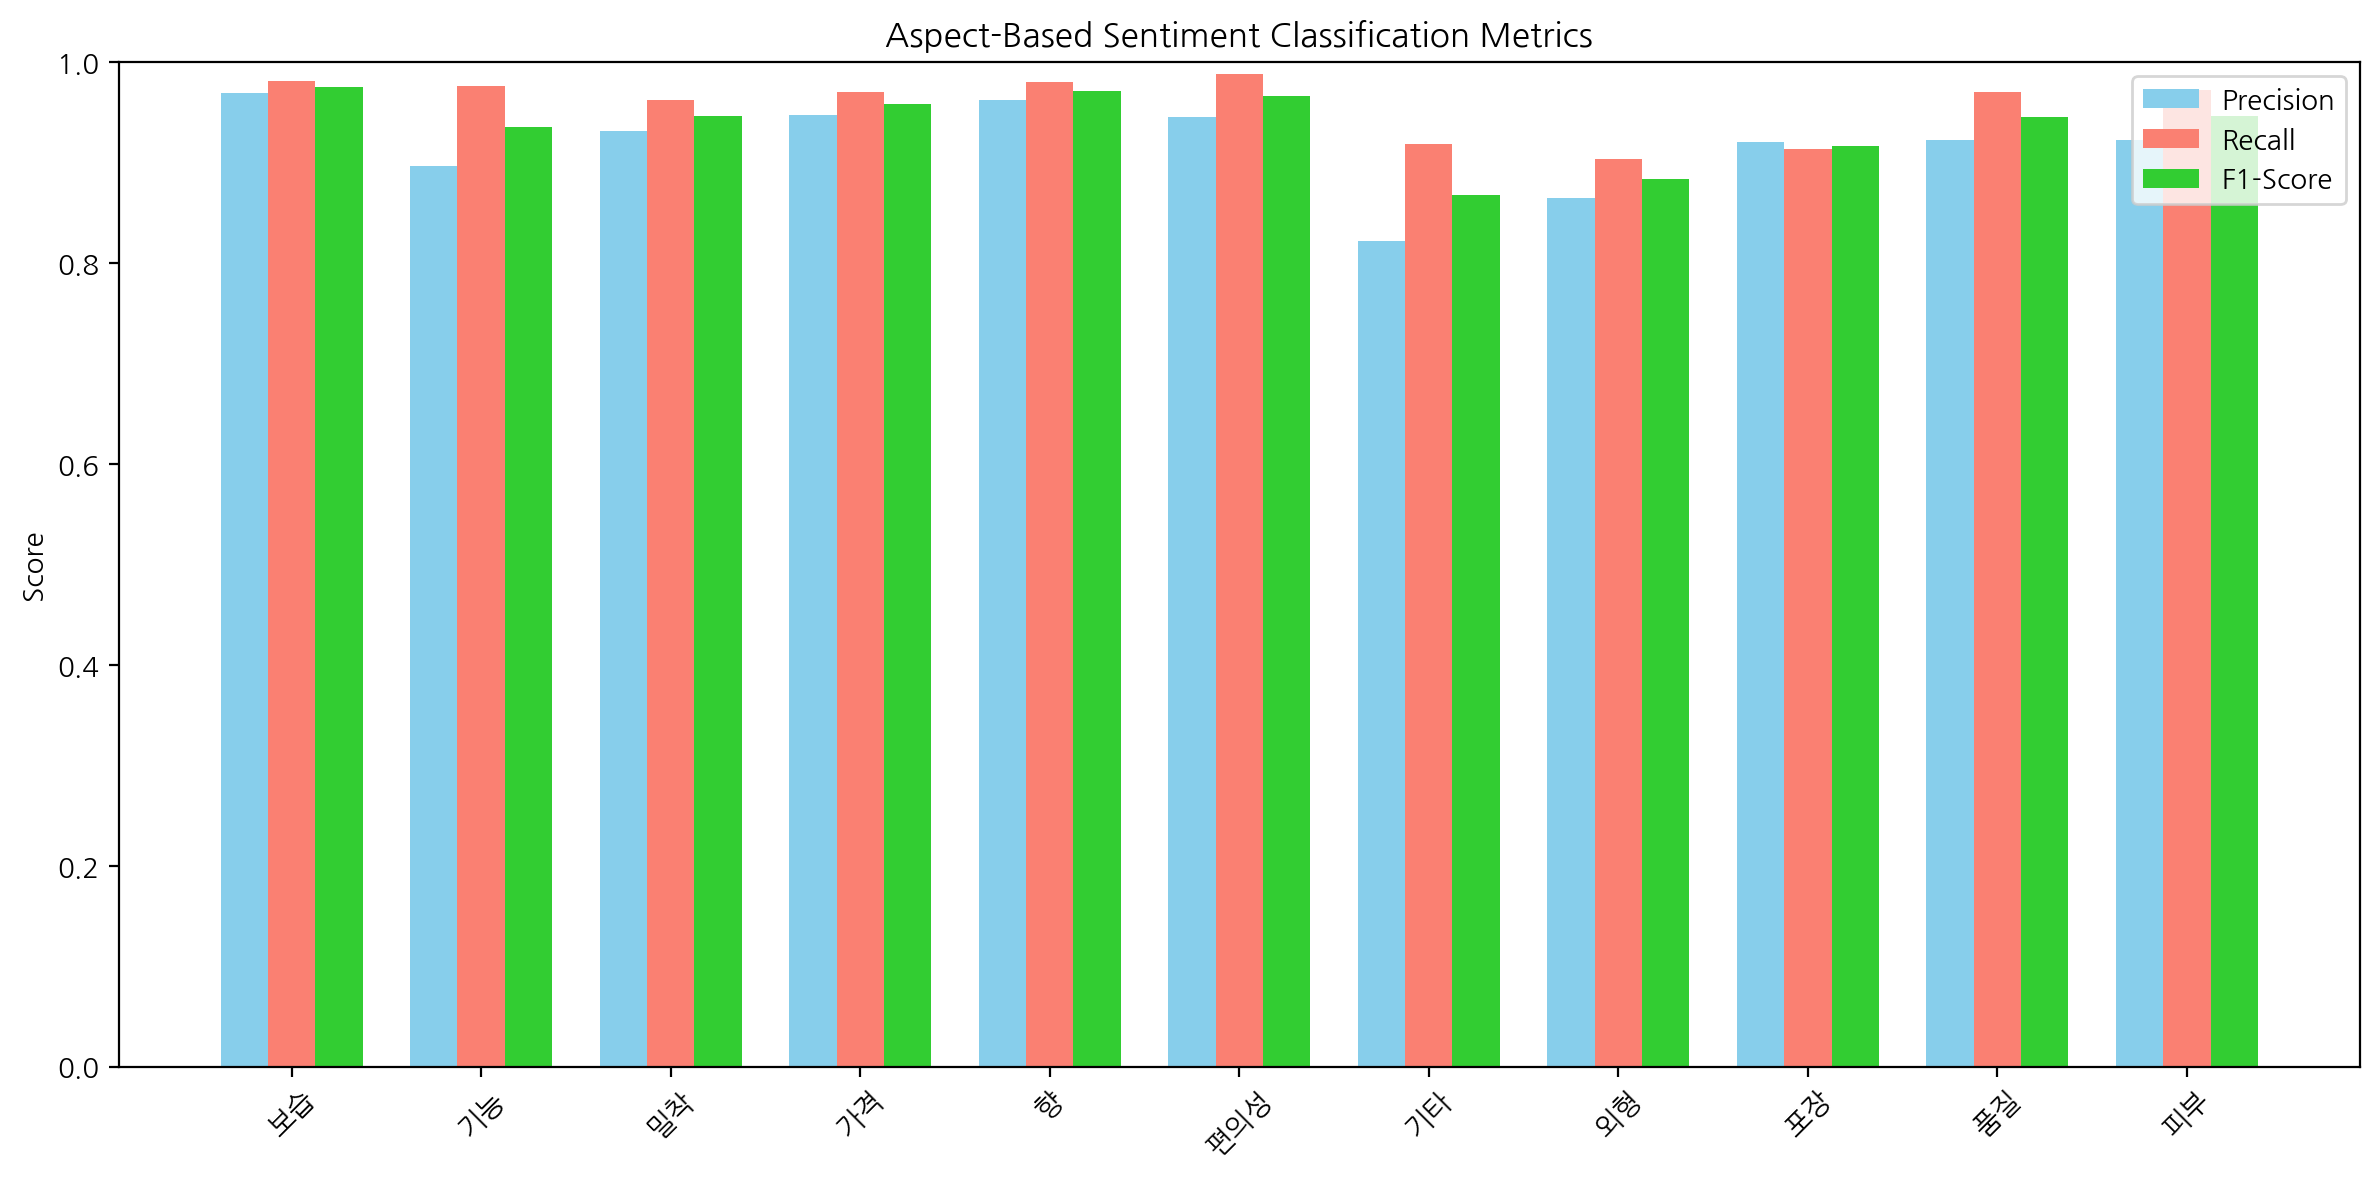

In [49]:
val_df_kb2 = val_ts_kb.to_pandas()
val_df_kb2['pred'] = preds1_case2
evaluate_by_aspect(val_df_kb2, aspects)

In [ ]:
#############################################################################################################

In [48]:
# 평가
print("Model2(RoBERTa) Accuracy:", accuracy_score(labels2_case2, preds2_case2))
print(classification_report(labels2_case2, preds2_case2, target_names=["Negative", "Positive"]))

val2 = val_ts_kr.to_pandas()
val2['pred'] = preds2_case2
val2[['text', 'aspect', 'label', 'pred']].head()

Model2(RoBERTa) Accuracy: 0.9256666666666666
              precision    recall  f1-score   support

    Negative       0.90      0.84      0.87       878
    Positive       0.93      0.96      0.95      2122

    accuracy                           0.93      3000
   macro avg       0.92      0.90      0.91      3000
weighted avg       0.92      0.93      0.92      3000



,text,aspect,label,pred
0,배송은 느렸구요 사용감은 좋아요. 남성 향이 강하니 참고하시고 세정력은 좋네요.,기능,1,1
1,안녕하세요~ 좋아하는 남친에게 ㅇㅇㅇ향수 어떨까요~ 겨울이 생일인 남자친구에게 선물...,편의성,1,1
2,용량도 크고 향도 강하지 않아서 괜찮습니다. 자극적이지 않아서 좋은 것 같아요.,피부,1,1
3,이름대로 무향에 보들보들 발림성이 부드러운 립밤이네요 아이가 용기의 OOO도 OOO...,향,1,1
4,다른 립밤은 온도에 따라 녹고 하는데 그런 것 없이 입술 탄력이 쫀쫀하게 잘 유지되...,향,1,1


=== 보습 ===
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90        69
    Positive       0.98      0.98      0.98       323

    accuracy                           0.96       392
   macro avg       0.94      0.94      0.94       392
weighted avg       0.96      0.96      0.96       392

=== 기능 ===
              precision    recall  f1-score   support

    Negative       0.86      0.76      0.81       108
    Positive       0.92      0.96      0.94       303

    accuracy                           0.91       411
   macro avg       0.89      0.86      0.87       411
weighted avg       0.90      0.91      0.90       411

=== 밀착 ===
              precision    recall  f1-score   support

    Negative       0.91      0.79      0.85        92
    Positive       0.92      0.97      0.95       241

    accuracy                           0.92       333
   macro avg       0.92      0.88      0.90       333
weighted avg       0.92      0.92      0.

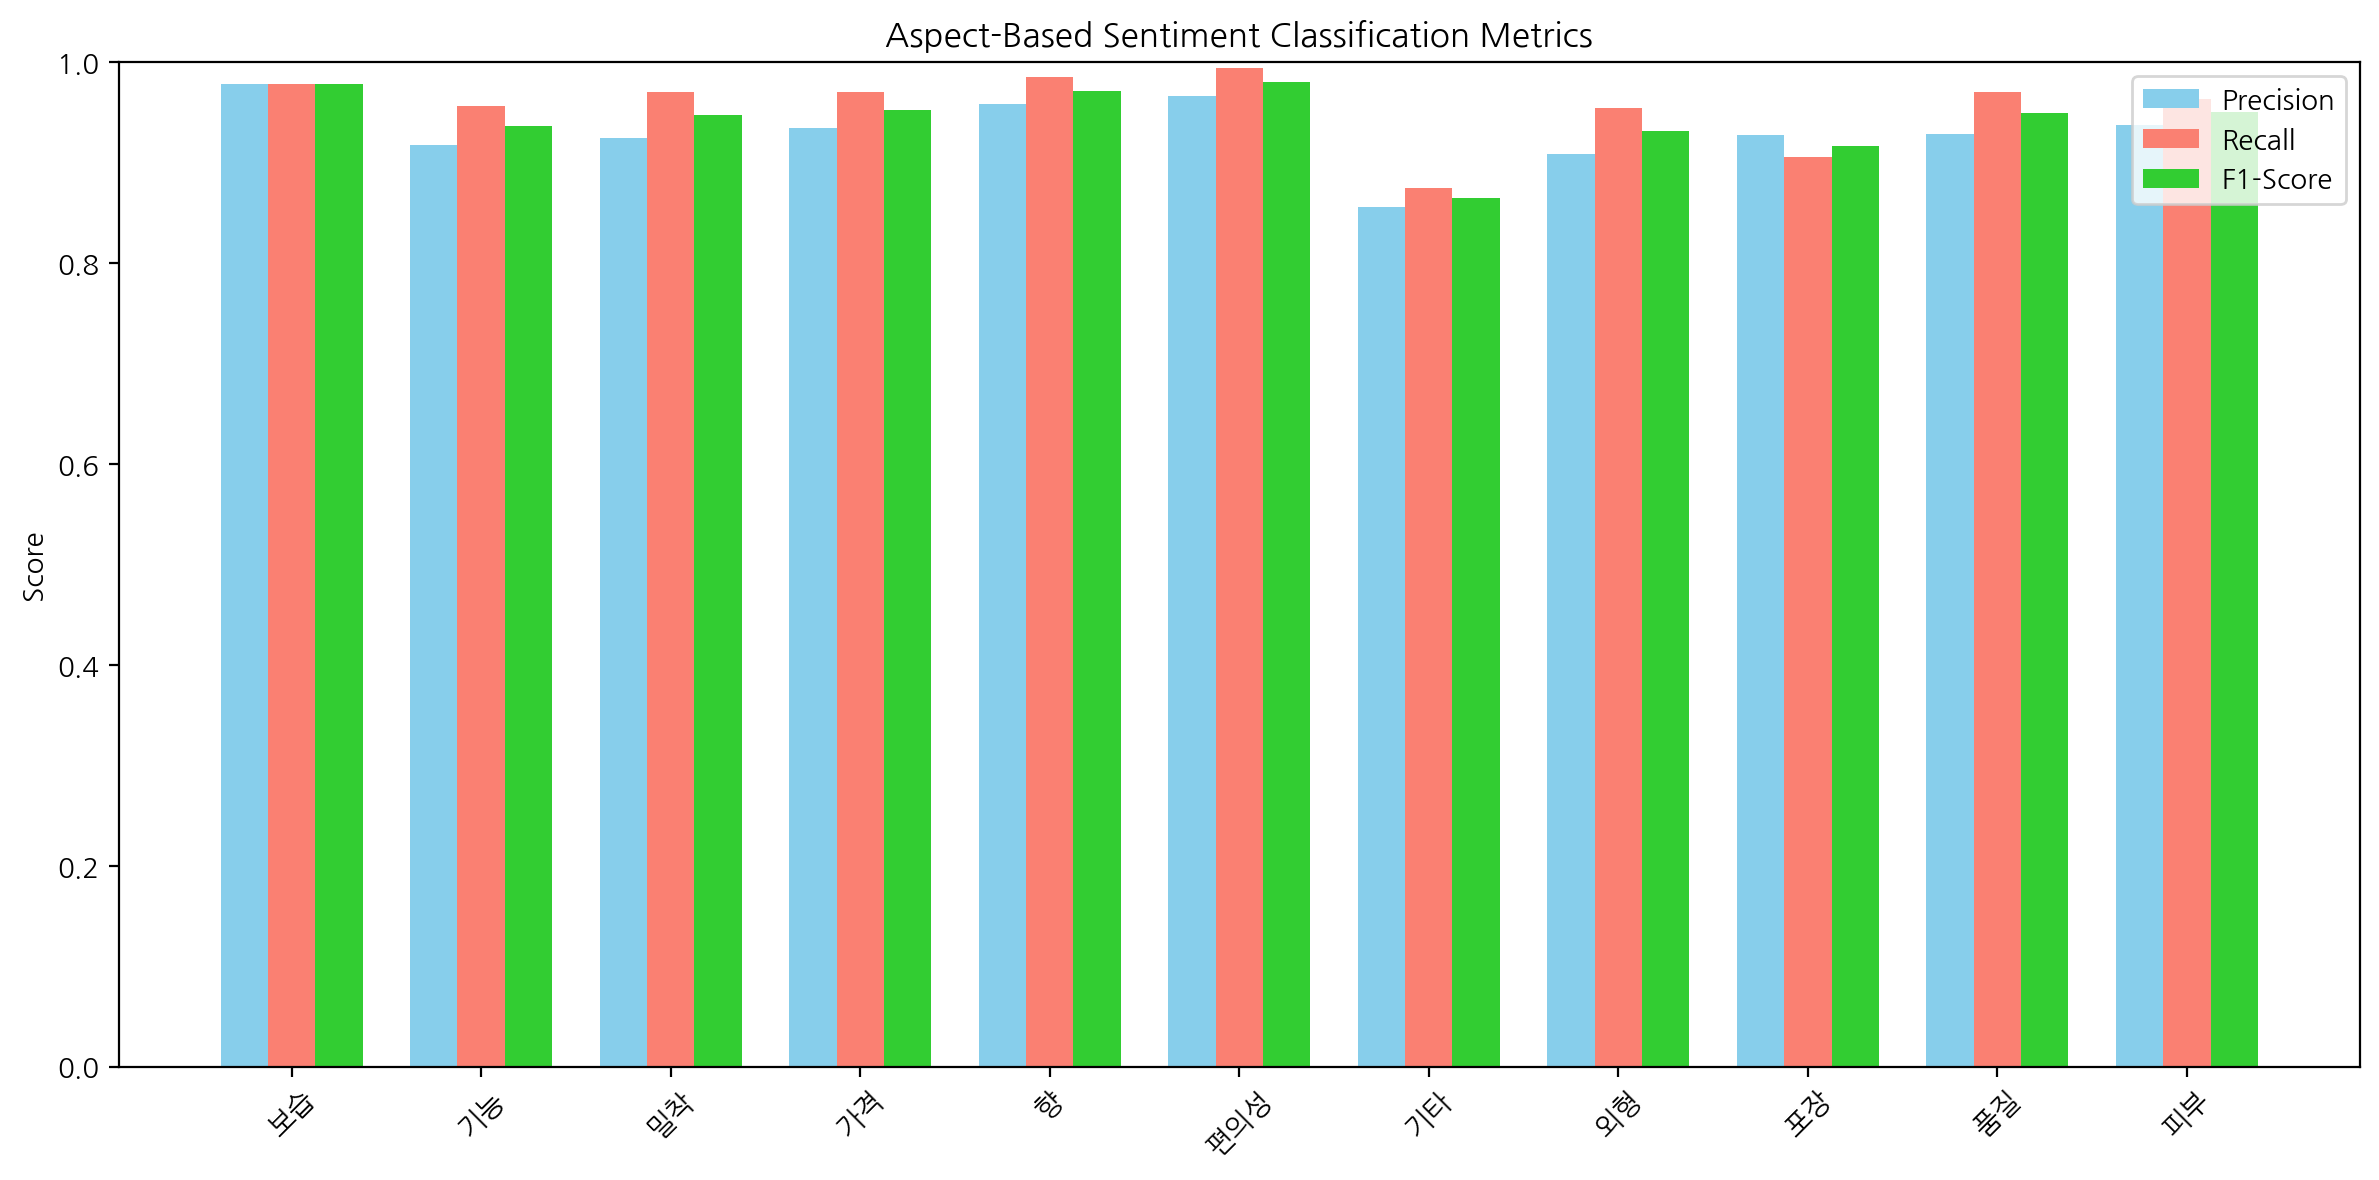

In [50]:
val_df_kr2 = val_ts_kr.to_pandas()
val_df_kr2['pred'] = preds2_case2
evaluate_by_aspect(val_df_kr2, aspects)

##추가진행

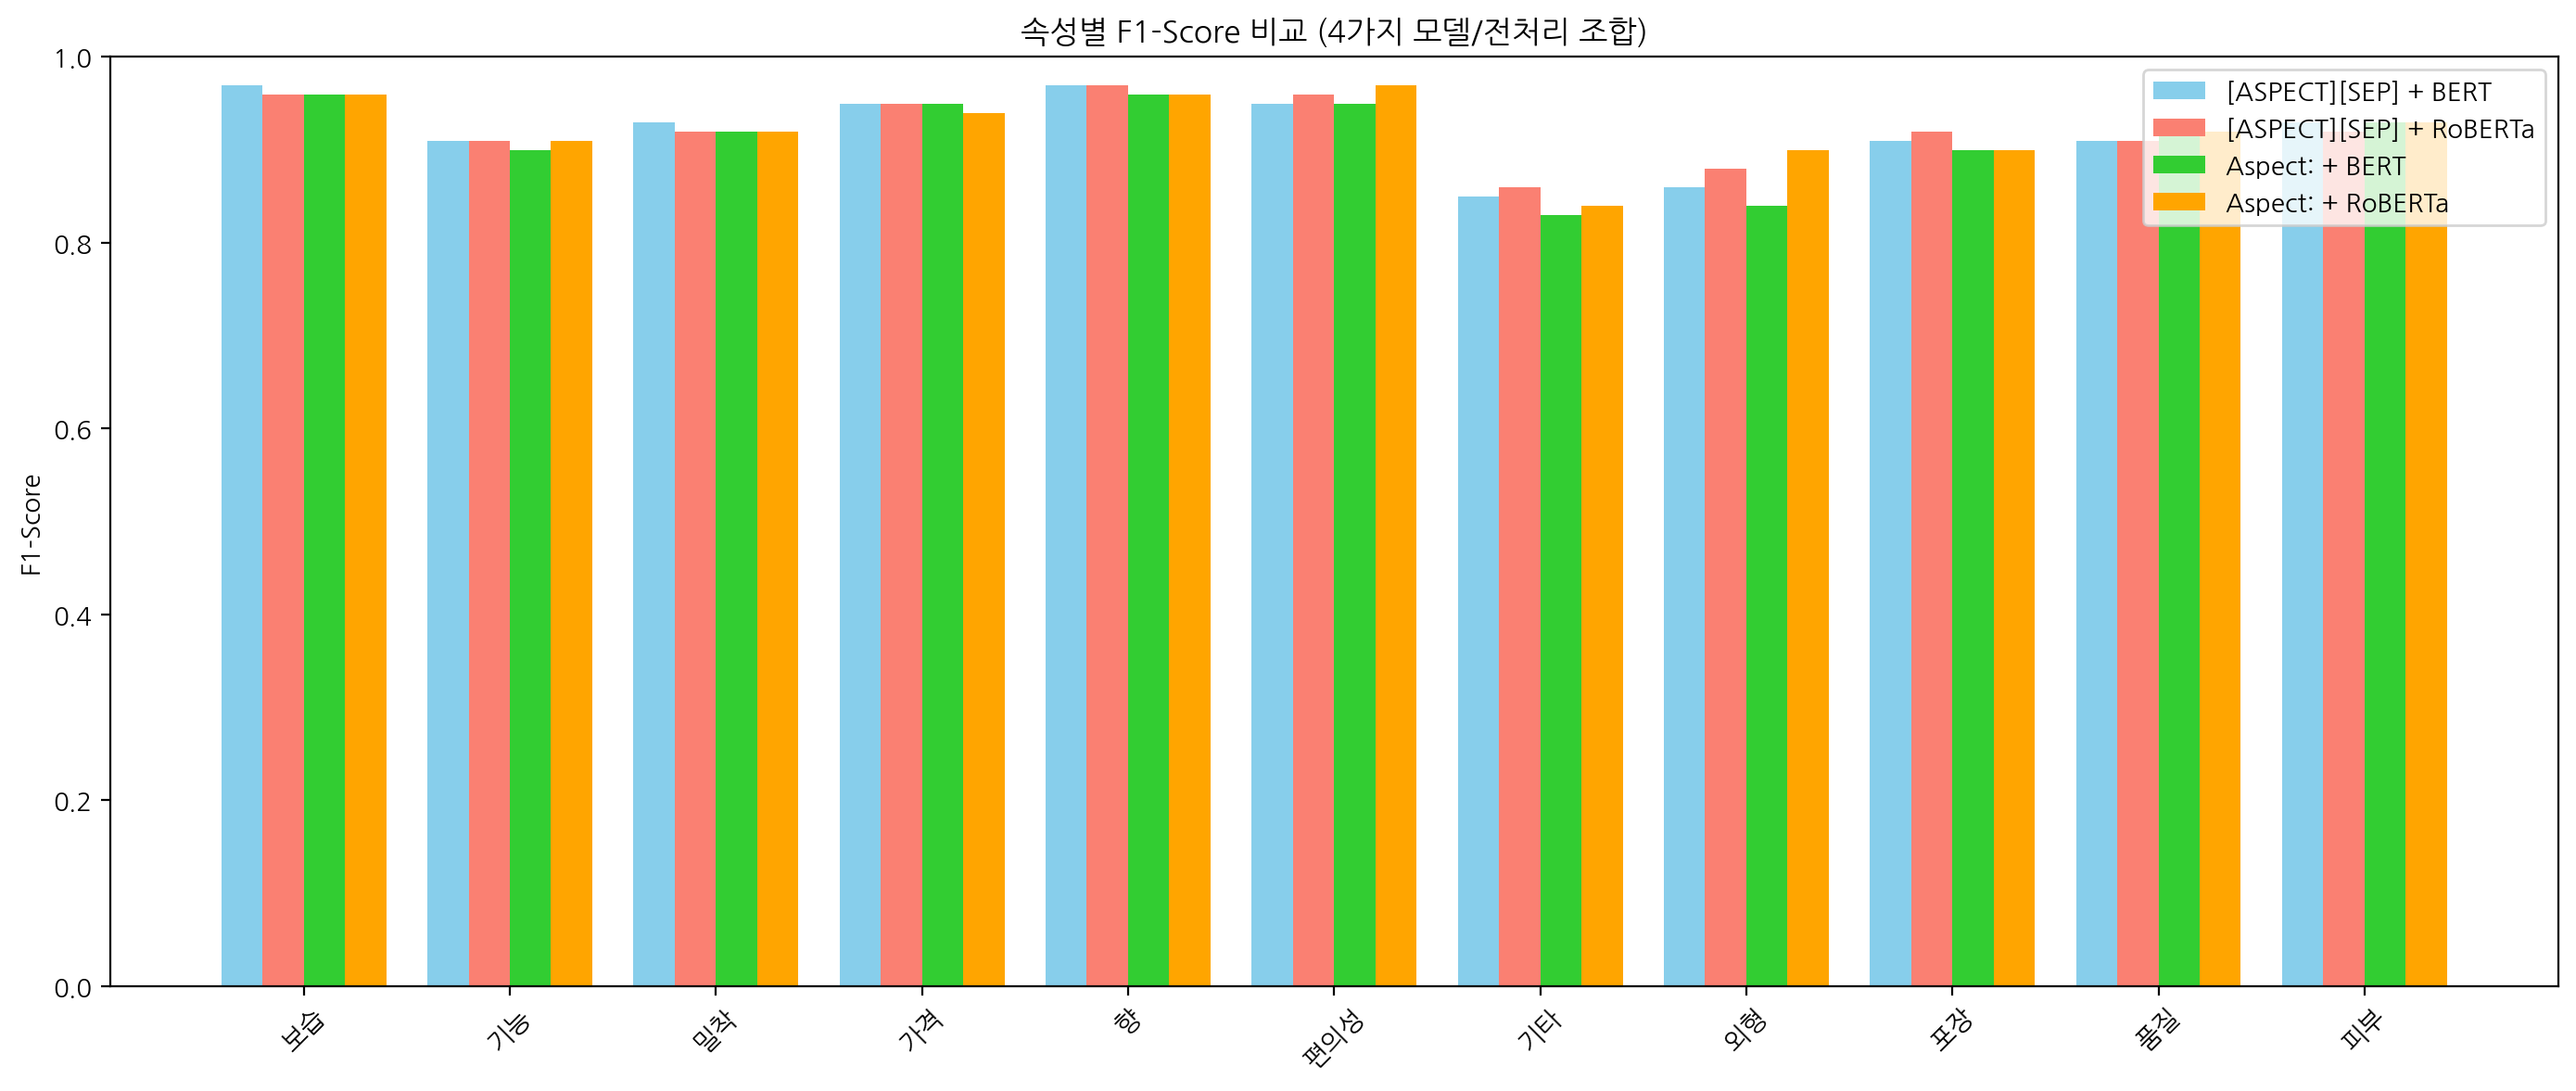

In [51]:
f1_case1_kb = [0.97, 0.91, 0.93, 0.95, 0.97, 0.95, 0.85, 0.86, 0.91, 0.91, 0.93]  # [ASPECT] + BERT
f1_case1_kr = [0.96, 0.91, 0.92, 0.95, 0.97, 0.96, 0.86, 0.88, 0.92, 0.91, 0.92]  # [ASPECT] + RoBERTa
f1_case2_kb = [0.96, 0.90, 0.92, 0.95, 0.96, 0.95, 0.83, 0.84, 0.90, 0.92, 0.93]  # Aspect: 문장 + BERT
f1_case2_kr = [0.96, 0.91, 0.92, 0.94, 0.96, 0.97, 0.84, 0.90, 0.90, 0.92, 0.93]  # Aspect: 문장 + RoBERTa

x = np.arange(len(aspects))
width = 0.2

plt.figure(figsize=(14,6))
plt.bar(x - 1.5*width, f1_case1_kb, width, label='[ASPECT][SEP] + BERT', color='skyblue')
plt.bar(x - 0.5*width, f1_case1_kr, width, label='[ASPECT][SEP] + RoBERTa', color='salmon')
plt.bar(x + 0.5*width, f1_case2_kb, width, label='Aspect: + BERT', color='limegreen')
plt.bar(x + 1.5*width, f1_case2_kr, width, label='Aspect: + RoBERTa', color='orange')

plt.xticks(x, aspects, rotation=45)
plt.ylabel('F1-Score')
plt.ylim(0,1)
plt.title('속성별 F1-Score 비교 (4가지 모델/전처리 조합)')
plt.legend()
plt.tight_layout()
plt.show()

결과 해석:
1. 문장 방식
- [ASPECT]+[SEP] 구조가 전체적으로 차이로 더 좋은 모습을 보이고 있다.
- 하지만, 해당 표를 보고 Gemini와 GPT는 ASPECT: 구조가 더 성능이 좋다고 말한다.
   - 결과를 AI에게 물어보지 말고, 직접 보고 비즈니스적으로 분석하는 연습을 해야겠다고 느꼈다.
2. 모델
- 전반적으로 RoBERTa가 성능이 좋게 나오고 있다.
- 특히, 애매한 부분(기타, 외형, 포장)등에선 RoBERTa의 성능이 좋게 나오고 있다.